In [81]:
from pyspark.sql.types import StructType, StructField
from pyspark.sql.types import DoubleType, IntegerType,StringType, FloatType
import pyspark
from pyspark.sql import SparkSession
import os
from pyspark.sql.functions import date_format
from pyspark.sql.types import *
from pyspark.sql.functions import *
from pyspark.sql.functions import from_unixtime, col
from pyspark.sql import functions as F
from datetime import datetime

In [ ]:
full_path_to_warehouse = 's3a://cdcwarehouse/'
# Bessie için kullanacağımız branch 
branch_name = "main"
# Nessie authentication türü. Diğer seçenekler (NONE, BEARER, OAUTH2 or AWS)
auth_type = "NONE"
# AWS S3 yerine MinIO kullandığımız için. Spark'a amazona gitme burada kal demek için.
s3_endpoint = "http://miniostorage:6060"
# MinIO'ya erişim için. Bunlar root olarak docker-compose içinde belirtiliyor. Bu haliyle canlı ortamlarda kullanılmamalıdır.
secretAccessKey='buYZdsJYQW9m2mUsfUYR0jQuck3vPkfARA9ibhGD'
accessKeyId='ut5zhdn3MtYRq7gVDxN3'
nessie_url = "http://nessie:19120/api/v1"



CATALOG_NAME = "nessie"
DB_NAME = "demo"

BRONZE_TABLE_NAME = "rawdata"
SILVER_TABLE_NAME = "users"
GOLDEN_TABLE_NAME = "activeusers"

DEV_BRACH_NAME = "develop"
TAG_NAME = "latest"

In [83]:

spark = (
    SparkSession.builder
    .master("local")
    .appName("CDC-Streammming")
    .config("spark.driver.memory", "16g")
    .config("spark.hadoop.fs.s3a.aws.credentials.provider",
                 "org.apache.hadoop.fs.s3a.SimpleAWSCredentialsProvider")\
    .config('spark.jars.packages','org.projectnessie.nessie-integrations:nessie-spark-extensions-3.3_2.12:0.102.2,'
            'org.apache.iceberg:iceberg-spark-runtime-3.3_2.12:1.5.2,'
            'org.apache.hadoop:hadoop-aws:3.3.2,'
            'software.amazon.awssdk:bundle:2.30.11,'
            'io.delta:delta-spark_2.12:3.3.0,'
            'org.apache.spark:spark-sql_2.12:3.3.2,'
            'org.apache.spark:spark-sql-kafka-0-10_2.12:3.3.2')
    .config("spark.hadoop.fs.s3a.access.key", accessKeyId)
    .config("spark.hadoop.fs.s3a.secret.key", secretAccessKey)
    .config("spark.hadoop.fs.s3a.path.style.access", True)
    .config("spark.hadoop.fs.s3a.impl", "org.apache.hadoop.fs.s3a.S3AFileSystem")
    .config("spark.hadoop.fs.s3a.endpoint", s3_endpoint)
    .config("fs.s3a.connection.ssl.enabled", "false")
    .config('spark.sql.extensions', 'org.apache.iceberg.spark.extensions.IcebergSparkSessionExtensions,'
            'org.projectnessie.spark.extensions.NessieSparkSessionExtensions')

    #Configuring Catalog
    .config("spark.sql.catalog.nessie_catalog", "org.apache.iceberg.nessie.NessieCatalog")
    .config("spark.sql.catalog.nessie.format-version", "2")
    .config("spark.sql.catalog.nessie.uri", nessie_url)
    .config("spark.sql.catalog.nessie.ref", branch_name)
    .config("spark.sql.catalog.nessie.authentication.type", auth_type)
    .config("spark.sql.catalog.nessie", "org.apache.iceberg.spark.SparkCatalog")
    .config("spark.sql.catalog.nessie.catalog-impl", "org.apache.iceberg.nessie.NessieCatalog")
    .config("spark.sql.catalog.nessie.warehouse", full_path_to_warehouse)
    .config("fs.s3a.connection.ssl.enabled", "false")
    # Spark Session'da GC özelliğini etkinleştir
    .config("spark.sql.catalog.nessie.gc.enabled", "true")
    .getOrCreate()
)


# 💾Namespace Nedir?
Namespace, Nessie içinde mantıksal bir kapsayıcı (container) veya organizasyon birimi olarak çalışır. Genellikle veritabanı şemaları (schema) veya hiyerarşik veri organizasyonu için kullanılır.

🔹 Kullanım Senaryoları:

- Farklı ekiplerin veya projelerin verilerini izole etmek
- Büyük veri kümelerini kategorilere ayırmak
- Veri erişimini organize etmek ve yetkilendirmeyi kolaylaştırmak


In [ ]:
spark.sql(f"SHOW NAMESPACES IN {CATALOG_NAME};").show()   #namespace listeleme

In [88]:
spark.sql(f"CREATE NAMESPACE IF NOT EXISTS {CATALOG_NAME}.{DB_NAME};").show()  #namespace oluşturma

++
||
++
++



In [ ]:
# spark.sql(f"DROP NAMESPACE IF EXISTS {CATALOG_NAME}.{DB_NAME} CASCADE;").show() #namespace silme

# 📌 Table Nedir?

Veri depolamak için kullanılan temel yapıdır. Nessie, tablo metadata’sını versiyon kontrollü bir şekilde yönetir.

In [ ]:
spark.sql(f"SHOW TABLES IN {CATALOG_NAME};").show()

In [91]:
spark.sql(f"""
        CREATE TABLE {CATALOG_NAME}.{DB_NAME}.{SILVER_TABLE_NAME} (
            change_ts TIMESTAMP, 
            username STRING,
            age INTEGER
        )
        USING iceberg
          """).show()

++
||
++
++



In [92]:
spark.sql(f"""
        CREATE TABLE {CATALOG_NAME}.{DB_NAME}.{GOLDEN_TABLE_NAME} (
            change_ts TIMESTAMP, 
            username STRING,
            age INTEGER,
            status BOOLEAN
        )
        USING iceberg
        PARTITIONED BY (DAY(change_ts));
          """).show()

++
||
++
++



In [94]:
spark.sql(f"DESCRIBE TABLE {CATALOG_NAME}.{DB_NAME}.{GOLDEN_TABLE_NAME}").show()

+--------------+---------------+-------+
|      col_name|      data_type|comment|
+--------------+---------------+-------+
|     change_ts|      timestamp|       |
|      username|         string|       |
|           age|            int|       |
|        status|        boolean|       |
|              |               |       |
|# Partitioning|               |       |
|        Part 0|days(change_ts)|       |
+--------------+---------------+-------+



In [ ]:
#spark.sql(f"DROP TABLE {CATALOG_NAME}.{DB_NAME}.{SILVER_TABLE_NAME}").show()

In [ ]:
#spark.sql(f"DROP TABLE {CATALOG_NAME}.{DB_NAME}.{GOLDEN_TABLE_NAME}").show()

# 📌 Create Raw Data for Bronze Layer

In [143]:
data = [
    (datetime(2024, 1, 20, 14, 30, 0), "user1", 15),
    (datetime(2024, 5, 21, 10, 15, 0), "user2", 30),
    (datetime(2024, 7, 11, 18, 45, 0), "user3", 22),
    (datetime(2024, 3, 22, 8, 5, 0), "user4", 27),
    (datetime(2024, 2, 21, 2, 5, 0), "user5", 10),
    
]

# DataFrame oluştur
df = spark.createDataFrame(data, ["change_ts", "username", "age"])

# DataFrame'i göster
df.show(truncate=False)

+-------------------+--------+---+
|change_ts          |username|age|
+-------------------+--------+---+
|2024-01-20 14:30:00|user1   |15 |
|2024-05-21 10:15:00|user2   |30 |
|2024-07-11 18:45:00|user3   |22 |
|2024-03-22 08:05:00|user4   |27 |
|2024-02-21 02:05:00|user5   |10 |
+-------------------+--------+---+



In [144]:
data = [
    (datetime(2024, 1, 20, 14, 30, 0), "2", 15),
    (datetime(2024, 5, 21, 10, 15, 0), "2", 30),
    (datetime(2024, 7, 11, 18, 45, 0), "2", 22),
    (datetime(2024, 3, 22, 8, 5, 0), "2", 27),
    (datetime(2024, 2, 21, 2, 5, 0), "2", 10),
    
]

# DataFrame oluştur
df = spark.createDataFrame(data, ["change_ts", "username", "age"])

# DataFrame'i göster
df.show(truncate=False)

+-------------------+--------+---+
|change_ts          |username|age|
+-------------------+--------+---+
|2024-01-20 14:30:00|2       |15 |
|2024-05-21 10:15:00|2       |30 |
|2024-07-11 18:45:00|2       |22 |
|2024-03-22 08:05:00|2       |27 |
|2024-02-21 02:05:00|2       |10 |
+-------------------+--------+---+



In [145]:
df.coalesce(1).write.parquet(f"s3a://rawusers/test")

In [148]:
df.coalesce(1).write.parquet(f"s3a://rawusers/test_3/test2")

## Get Parquet File From S3

In [98]:
df = spark.read.parquet(f"s3a://rawusers/{BRONZE_TABLE_NAME}/*.parquet")
df.show()

+-------------------+--------+---+
|          change_ts|username|age|
+-------------------+--------+---+
|2024-01-20 14:30:00|   user1| 15|
|2024-05-21 10:15:00|   user2| 30|
|2024-07-11 18:45:00|   user3| 22|
|2024-03-22 08:05:00|   user4| 27|
|2024-02-21 02:05:00|   user5| 10|
+-------------------+--------+---+



## Insert Silver Layer Table

In [99]:
# DataFrame'i geçici bir tabloya kaydet
df.createOrReplaceTempView("temp_table")

# Iceberg tablosuna veri ekleme
spark.sql(f"""
    INSERT INTO {CATALOG_NAME}.{DB_NAME}.{SILVER_TABLE_NAME}
    SELECT * FROM temp_table
""")

spark.sql(f"SELECT * FROM {CATALOG_NAME}.{DB_NAME}.{SILVER_TABLE_NAME}").show()

+-------------------+--------+---+
|          change_ts|username|age|
+-------------------+--------+---+
|2024-01-20 14:30:00|   user1| 15|
|2024-05-21 10:15:00|   user2| 30|
|2024-07-11 18:45:00|   user3| 22|
|2024-03-22 08:05:00|   user4| 27|
|2024-02-21 02:05:00|   user5| 10|
+-------------------+--------+---+



In [100]:
new_data = [(datetime(2025, 2, 21, 12, 0, 0), "new_user", 1)]
new_df = spark.createDataFrame(new_data, ["change_ts", "username", "age"])

In [101]:
new_df\
    .write.mode("append")\
    .insertInto(f"{CATALOG_NAME}.{DB_NAME}.{SILVER_TABLE_NAME}")

In [102]:
spark.sql(f"SELECT * FROM {CATALOG_NAME}.{DB_NAME}.{SILVER_TABLE_NAME}").show()

+-------------------+--------+---+
|          change_ts|username|age|
+-------------------+--------+---+
|2024-01-20 14:30:00|   user1| 15|
|2024-05-21 10:15:00|   user2| 30|
|2024-07-11 18:45:00|   user3| 22|
|2024-03-22 08:05:00|   user4| 27|
|2024-02-21 02:05:00|   user5| 10|
|2025-02-21 12:00:00|new_user|  1|
+-------------------+--------+---+



> Golden layer için Veriyi hazırlamamız gerekiyor. ETL süreci replikası olması adına yaşı 18 den küçüklerin statusunu false olarak ayaralaycağız 

In [103]:
silver_df = df.withColumn("status", when(df.age < 18, False).otherwise(True))
silver_df.show(truncate=False)

+-------------------+--------+---+------+
|change_ts          |username|age|status|
+-------------------+--------+---+------+
|2024-01-20 14:30:00|user1   |15 |false |
|2024-05-21 10:15:00|user2   |30 |true  |
|2024-07-11 18:45:00|user3   |22 |true  |
|2024-03-22 08:05:00|user4   |27 |true  |
|2024-02-21 02:05:00|user5   |10 |false |
+-------------------+--------+---+------+



In [104]:
silver_df\
    .writeTo(f"{CATALOG_NAME}.{DB_NAME}.{GOLDEN_TABLE_NAME}") \
    .partitionedBy("change_ts") \
    .append()  # Tabloyu append modunda güncelliyoruz

In [149]:
spark.sql(f"SELECT * FROM {CATALOG_NAME}.{DB_NAME}.{GOLDEN_TABLE_NAME}").show()

+-------------------+--------+---+------+
|          change_ts|username|age|status|
+-------------------+--------+---+------+
|2024-07-11 18:45:00|   user3| 22|  true|
|2024-05-21 10:15:00|   user2| 30|  true|
|2024-02-21 02:05:00|   user5| 10| false|
|2024-01-20 14:30:00|   user1| 15| false|
|2024-03-22 08:05:00|   user4| 27|  true|
+-------------------+--------+---+------+



-----

# ⚔ NESSIE ÖZELLİKLERİ

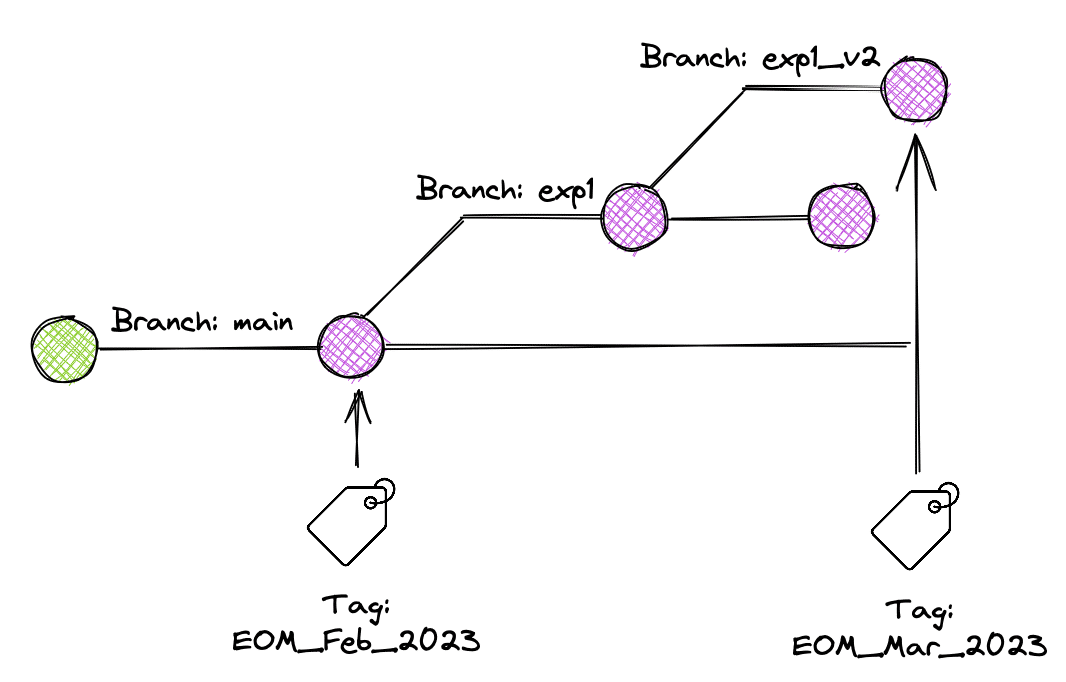

---

## 🔗 Branch Yapısı

In [106]:
spark.sql(f"ALTER TABLE {CATALOG_NAME}.{DB_NAME}.{SILVER_TABLE_NAME} CREATE BRANCH IF NOT EXISTS {DEV_BRACH_NAME}")

DataFrame[]

In [107]:
data = [
    (datetime(2024, 1, 20, 14, 30, 0), "test1", 12),
    (datetime(2024, 5, 21, 10, 15, 0), "test2", 22),
    (datetime(2024, 7, 11, 18, 45, 0), "test3", 32),
    ]

# DataFrame oluştur
test_df = spark.createDataFrame(data, ["change_ts", "username", "age"])

# DataFrame'i göster
test_df.show(truncate=False)

+-------------------+--------+---+
|change_ts          |username|age|
+-------------------+--------+---+
|2024-01-20 14:30:00|test1   |12 |
|2024-05-21 10:15:00|test2   |22 |
|2024-07-11 18:45:00|test3   |32 |
+-------------------+--------+---+



In [108]:
# develpo branchine test userlarını ekler

test_df.write.format("iceberg")\
  .option("branch", "develop")\
    .mode("append")\
    .save(f"{CATALOG_NAME}.{DB_NAME}.{SILVER_TABLE_NAME}")

In [109]:
spark.sql(f"SELECT * FROM {CATALOG_NAME}.{DB_NAME}.{SILVER_TABLE_NAME} VERSION AS OF '{DEV_BRACH_NAME}'").show()

+-------------------+--------+---+
|          change_ts|username|age|
+-------------------+--------+---+
|2025-02-21 12:00:00|new_user|  1|
|2024-01-20 14:30:00|   test1| 12|
|2024-05-21 10:15:00|   test2| 22|
|2024-07-11 18:45:00|   test3| 32|
|2024-01-20 14:30:00|   user1| 15|
|2024-05-21 10:15:00|   user2| 30|
|2024-07-11 18:45:00|   user3| 22|
|2024-03-22 08:05:00|   user4| 27|
|2024-02-21 02:05:00|   user5| 10|
+-------------------+--------+---+



In [110]:
spark.sql(f"SELECT * FROM {CATALOG_NAME}.{DB_NAME}.{SILVER_TABLE_NAME};").show()

+-------------------+--------+---+
|          change_ts|username|age|
+-------------------+--------+---+
|2024-01-20 14:30:00|   user1| 15|
|2024-05-21 10:15:00|   user2| 30|
|2024-07-11 18:45:00|   user3| 22|
|2024-03-22 08:05:00|   user4| 27|
|2024-02-21 02:05:00|   user5| 10|
|2025-02-21 12:00:00|new_user|  1|
+-------------------+--------+---+



> Buradan da anlaşılacağı üzere 'develop' branchine test userları eklendi. Eklenirken ham table'a ek olarak yazılıdı.

Şimdi bir de overwrite modunu kullanarak insert yapalım. Bu işlem sonucunda bu branchte sadece test userları olacaktır

In [111]:
data = [
    (datetime(2024, 1, 20, 14, 30, 0), "test4", 42),
    (datetime(2024, 5, 21, 10, 15, 0), "test5", 52),
    (datetime(2024, 7, 11, 18, 45, 0), "test6", 62),
]

# DataFrame oluştur
test_df_2 = spark.createDataFrame(data, ["change_ts", "username", "age"])

# DataFrame'i göster
test_df_2.show(truncate=False)

+-------------------+--------+---+
|change_ts          |username|age|
+-------------------+--------+---+
|2024-01-20 14:30:00|test4   |42 |
|2024-05-21 10:15:00|test5   |52 |
|2024-07-11 18:45:00|test6   |62 |
+-------------------+--------+---+



In [112]:
test_df_2.write.format("iceberg")\
  .option("branch", "develop")\
  .mode("overwrite")\
  .save(f"{CATALOG_NAME}.{DB_NAME}.{SILVER_TABLE_NAME}")

spark.sql(f"SELECT * FROM {CATALOG_NAME}.{DB_NAME}.{SILVER_TABLE_NAME} VERSION AS OF '{DEV_BRACH_NAME}'").show()

+-------------------+--------+---+
|          change_ts|username|age|
+-------------------+--------+---+
|2024-01-20 14:30:00|   test4| 42|
|2024-05-21 10:15:00|   test5| 52|
|2024-07-11 18:45:00|   test6| 62|
+-------------------+--------+---+



In [113]:
spark.sql(f"SELECT * FROM {CATALOG_NAME}.{DB_NAME}.{SILVER_TABLE_NAME};").show()

+-------------------+--------+---+
|          change_ts|username|age|
+-------------------+--------+---+
|2025-02-21 12:00:00|new_user|  1|
|2024-01-20 14:30:00|   user1| 15|
|2024-05-21 10:15:00|   user2| 30|
|2024-07-11 18:45:00|   user3| 22|
|2024-03-22 08:05:00|   user4| 27|
|2024-02-21 02:05:00|   user5| 10|
+-------------------+--------+---+



## 🎇 Tag Yapısı

In [114]:
spark.sql("LIST REFERENCES IN nessie").show()

+-------+----+--------------------+
|refType|name|                hash|
+-------+----+--------------------+
| Branch|main|75d0ea9e53935e845...|
+-------+----+--------------------+



- latest adında bir tag oluşturalım.
- RETAIN n_days DAYS komutu, veriye bir etiket veya başka bir işaretçi uygulandığında, o etiketin ya da işaretçinin 60 gün boyunca geçerli olacağı ve sonrasında silineceği anlamına gelir.

In [115]:
spark.sql(f"ALTER TABLE {CATALOG_NAME}.{DB_NAME}.{SILVER_TABLE_NAME} CREATE TAG IF NOT EXISTS {TAG_NAME} RETAIN 1 DAYS")

DataFrame[]

> Oluşturulan tag'i silmek için

In [116]:
spark.sql(f"SELECT * FROM {CATALOG_NAME}.{DB_NAME}.{SILVER_TABLE_NAME}").show()

+-------------------+--------+---+
|          change_ts|username|age|
+-------------------+--------+---+
|2025-02-21 12:00:00|new_user|  1|
|2024-01-20 14:30:00|   user1| 15|
|2024-05-21 10:15:00|   user2| 30|
|2024-07-11 18:45:00|   user3| 22|
|2024-03-22 08:05:00|   user4| 27|
|2024-02-21 02:05:00|   user5| 10|
+-------------------+--------+---+



In [117]:
tagdf = spark.read\
  .format("iceberg")\
  .option("path", f"{CATALOG_NAME}.{DB_NAME}.{SILVER_TABLE_NAME}")\
  .option("ref", f"refs/tags/{TAG_NAME}")\
  .load()

tagdf.show()

+-------------------+--------+---+
|          change_ts|username|age|
+-------------------+--------+---+
|2025-02-21 12:00:00|new_user|  1|
|2024-01-20 14:30:00|   user1| 15|
|2024-05-21 10:15:00|   user2| 30|
|2024-07-11 18:45:00|   user3| 22|
|2024-03-22 08:05:00|   user4| 27|
|2024-02-21 02:05:00|   user5| 10|
+-------------------+--------+---+



- Tag'lediğim hali ile bronze layerdaki veri aynı, yani tagi çalıştırdığım andaki tablonun durumunu aldı.

-> Şimdi silver layer'a yeni verilere değiştirelim Tag'e gelcek mi?

In [118]:
data = [
    (datetime(2025, 1, 20, 14, 30, 0), "test_tag1", 42),
    (datetime(2025, 1, 20, 10, 15, 0), "test_tag2", 52),
    (datetime(2025, 1, 20, 18, 45, 0), "test_tag3", 62),
]

# DataFrame oluştur
test_df_tag = spark.createDataFrame(data, ["change_ts", "username", "age"])

# DataFrame'i göster
test_df_tag.show(truncate=False)

+-------------------+---------+---+
|change_ts          |username |age|
+-------------------+---------+---+
|2025-01-20 14:30:00|test_tag1|42 |
|2025-01-20 10:15:00|test_tag2|52 |
|2025-01-20 18:45:00|test_tag3|62 |
+-------------------+---------+---+



In [119]:
test_df_tag.write.format("iceberg")\
  .mode("overwrite")\
  .save(f"{CATALOG_NAME}.{DB_NAME}.{SILVER_TABLE_NAME}")

spark.sql(f"SELECT * FROM {CATALOG_NAME}.{DB_NAME}.{SILVER_TABLE_NAME} ").show()

+-------------------+---------+---+
|          change_ts| username|age|
+-------------------+---------+---+
|2025-01-20 14:30:00|test_tag1| 42|
|2025-01-20 10:15:00|test_tag2| 52|
|2025-01-20 18:45:00|test_tag3| 62|
+-------------------+---------+---+



In [120]:
# tag query
tagdf = spark.read\
  .format("iceberg")\
  .option("path", f"{CATALOG_NAME}.{DB_NAME}.{SILVER_TABLE_NAME}")\
  .option("tag", "latest")\
  .load()

tagdf.show()

+-------------------+--------+---+
|          change_ts|username|age|
+-------------------+--------+---+
|2025-02-21 12:00:00|new_user|  1|
|2024-01-20 14:30:00|   user1| 15|
|2024-05-21 10:15:00|   user2| 30|
|2024-07-11 18:45:00|   user3| 22|
|2024-03-22 08:05:00|   user4| 27|
|2024-02-21 02:05:00|   user5| 10|
+-------------------+--------+---+



In [121]:
spark.sql(f"""
    SELECT * FROM  
   {CATALOG_NAME}.{DB_NAME}.{SILVER_TABLE_NAME}
    """).show()

+-------------------+---------+---+
|          change_ts| username|age|
+-------------------+---------+---+
|2025-01-20 14:30:00|test_tag1| 42|
|2025-01-20 10:15:00|test_tag2| 52|
|2025-01-20 18:45:00|test_tag3| 62|
+-------------------+---------+---+



- Görüldüğü üzere silver layer test_tag userlarla doluyken "latest" tagı ilk başta oluşturduğumuz df ile dolu

## ⏳ Time Travelling

In [122]:
spark.sql(f"SELECT * FROM {CATALOG_NAME}.{DB_NAME}.{SILVER_TABLE_NAME}.history;").show(truncate=False)

+-----------------------+-------------------+-------------------+-------------------+
|made_current_at        |snapshot_id        |parent_id          |is_current_ancestor|
+-----------------------+-------------------+-------------------+-------------------+
|2025-02-28 11:57:31.145|1854513838490596194|null               |true               |
|2025-02-28 11:59:09.741|8858305849662701554|1854513838490596194|true               |
|2025-02-28 12:12:11.509|34133123747997440  |8858305849662701554|true               |
+-----------------------+-------------------+-------------------+-------------------+



## Snapshot ID ile TT

In [123]:
spark.sql(f"SELECT * FROM {CATALOG_NAME}.{DB_NAME}.{SILVER_TABLE_NAME} VERSION AS OF 34133123747997440;").show()


+-------------------+---------+---+
|          change_ts| username|age|
+-------------------+---------+---+
|2025-01-20 14:30:00|test_tag1| 42|
|2025-01-20 10:15:00|test_tag2| 52|
|2025-01-20 18:45:00|test_tag3| 62|
+-------------------+---------+---+



In [124]:
spark.sql(f"SELECT * FROM {CATALOG_NAME}.{DB_NAME}.{SILVER_TABLE_NAME} VERSION AS OF 8858305849662701554;").show()


+-------------------+--------+---+
|          change_ts|username|age|
+-------------------+--------+---+
|2024-01-20 14:30:00|   user1| 15|
|2024-05-21 10:15:00|   user2| 30|
|2024-07-11 18:45:00|   user3| 22|
|2024-03-22 08:05:00|   user4| 27|
|2024-02-21 02:05:00|   user5| 10|
|2025-02-21 12:00:00|new_user|  1|
+-------------------+--------+---+



In [136]:
spark.sql(f"SELECT * FROM {CATALOG_NAME}.{DB_NAME}.{SILVER_TABLE_NAME} TIMESTAMP AS OF '2025-03-01'; " ).show()

+-------------------+---------+---+
|          change_ts| username|age|
+-------------------+---------+---+
|2025-01-20 14:30:00|test_tag1| 42|
|2025-01-20 10:15:00|test_tag2| 52|
|2025-01-20 18:45:00|test_tag3| 62|
+-------------------+---------+---+



---

# Insert Testi

In [ ]:
spark.sql(f"SELECT * FROM {CATALOG_NAME}.{DB_NAME}.{SILVER_TABLE_NAME};").show(truncate=False)

In [ ]:
data = [
    (datetime(2025, 2, 20, 14, 30, 0), "burak", 42),
    (datetime(2025, 2, 20, 10, 15, 0), "test_tag2", 52),
    (datetime(2025, 2, 20, 18, 45, 0), "test_tag3", 62),
]

# DataFrame oluştur
tdf = spark.createDataFrame(data, ["change_ts", "username", "age"])


tdf.write.format("iceberg")\
  .mode("append")\
  .save(f"{CATALOG_NAME}.{DB_NAME}.{SILVER_TABLE_NAME}")

spark.sql(f"SELECT * FROM {CATALOG_NAME}.{DB_NAME}.{SILVER_TABLE_NAME} ").show()

# Bakım

In [137]:
spark.sql(f"""
  ALTER TABLE {CATALOG_NAME}.{DB_NAME}.{SILVER_TABLE_NAME} SET TBLPROPERTIES (
    'gc.enabled' = 'true'
  )
""")

DataFrame[]

##  Snapshot Temizleme (Expire Snapshots)

iceberg, her veri ekleme, silme veya güncelleme işlemi için bir snapshot (anlık görüntü) oluşturur.

Bu snapshot'lar zamanla birikir ve gereksiz disk kullanımı ile okuma/yazma performansını düşürebilir.

Bu işlem, belirli kriterleri karşılayan snapshot'ları Iceberg metadata'dan kaldırarak tabloyu optimize eder.

### Ne Zaman Kullanılır?

- Eski snapshot'lar çok birikmişse ve depolama alanı dolmaya başlamışsa
- Tablo çok büyükse ve sorgu süreleri uzamışsa
- Sistem performansını artırmak ve metadata yönetimini optimize etmek için düzenli olarak
- Gereksiz eski veri değişikliklerini silmek ve sadece en yeni snapshot'ları korumak için

In [138]:
spark.sql(f"SELECT * FROM {CATALOG_NAME}.{DB_NAME}.{SILVER_TABLE_NAME}.snapshots").show()

+--------------------+-------------------+-------------------+---------+--------------------+--------------------+
|        committed_at|        snapshot_id|          parent_id|operation|       manifest_list|             summary|
+--------------------+-------------------+-------------------+---------+--------------------+--------------------+
|2025-02-28 11:57:...|1854513838490596194|               null|   append|s3a://cdcwarehous...|{spark.app.id -> ...|
|2025-02-28 11:59:...|8858305849662701554|1854513838490596194|   append|s3a://cdcwarehous...|{spark.app.id -> ...|
|2025-02-28 12:05:...|1823357414104723766|8858305849662701554|   append|s3a://cdcwarehous...|{spark.app.id -> ...|
|2025-02-28 12:06:...|2846048799587913744|1823357414104723766|overwrite|s3a://cdcwarehous...|{spark.app.id -> ...|
|2025-02-28 12:12:...|  34133123747997440|8858305849662701554|overwrite|s3a://cdcwarehous...|{spark.app.id -> ...|
+--------------------+-------------------+-------------------+---------+--------

In [151]:
a = spark.sql(f"SELECT * FROM {CATALOG_NAME}.{DB_NAME}.{SILVER_TABLE_NAME}.snapshots")
a.select("summary").collect()

[Row(summary={'spark.app.id': 'local-1740660437651', 'changed-partition-count': '1', 'added-data-files': '1', 'total-equality-deletes': '0', 'added-records': '5', 'total-position-deletes': '0', 'added-files-size': '997', 'total-delete-files': '0', 'total-files-size': '997', 'total-records': '5', 'total-data-files': '1'}),
 Row(summary={'spark.app.id': 'local-1740660437651', 'changed-partition-count': '1', 'added-data-files': '1', 'total-equality-deletes': '0', 'added-records': '1', 'total-position-deletes': '0', 'added-files-size': '963', 'total-delete-files': '0', 'total-files-size': '1960', 'total-records': '6', 'total-data-files': '2'}),
 Row(summary={'spark.app.id': 'local-1740660437651', 'changed-partition-count': '1', 'added-data-files': '1', 'total-equality-deletes': '0', 'added-records': '3', 'total-position-deletes': '0', 'added-files-size': '965', 'total-delete-files': '0', 'total-files-size': '2925', 'total-records': '9', 'total-data-files': '3'}),
 Row(summary={'added-data-

In [152]:
spark.sql(f"""
  CALL nessie.system.expire_snapshots(
    table => '{CATALOG_NAME}.{DB_NAME}.{SILVER_TABLE_NAME}',
    older_than => TIMESTAMP '2025-02-27 00:00:00',
    retain_last => 1
  )
""").show()

+------------------------+-----------------------------------+-----------------------------------+----------------------------+----------------------------+------------------------------+
|deleted_data_files_count|deleted_position_delete_files_count|deleted_equality_delete_files_count|deleted_manifest_files_count|deleted_manifest_lists_count|deleted_statistics_files_count|
+------------------------+-----------------------------------+-----------------------------------+----------------------------+----------------------------+------------------------------+
|                       0|                                  0|                                  0|                           0|                           0|                             0|
+------------------------+-----------------------------------+-----------------------------------+----------------------------+----------------------------+------------------------------+



## Orphan Dosyaları Temizleme (VACUUM)

 Iceberg metadata'larında artık referans gösterilmeyen veri dosyalarıdır. Genellikle başarısız işlemler, yanlışlıkla bırakılan dosyalar veya metadatanın güncellenmemesi gibi durumlar sonucu oluşur.

In [154]:
spark.sql(f"""
  CALL nessie.system.remove_orphan_files(
    table => '{CATALOG_NAME}.{DB_NAME}.{SILVER_TABLE_NAME}',
    older_than => TIMESTAMP '2024-02-28 00:00:00'
  )
""").show()

+--------------------+
|orphan_file_location|
+--------------------+
+--------------------+



## Manifest Optimizasyonu

Manifest dosyaları, Iceberg tablosundaki veri dosyalarına dair metadata'yı içerir. Bu dosyalar, veri dosyalarının bulunduğu yerler, segmentler, dosya boyutları ve tablonun mevcut durumu hakkında bilgi içerir.

Manifest'lerin zaman içinde güncel tutulması gerekir, çünkü veri ekleme, silme, güncelleme gibi işlemler sonucu eski manifest dosyaları pasifleşebilir ya da bozulabilir. Bu durumda, yeni ve doğru manifest dosyaları oluşturulmalıdır.

In [142]:
# Manifest'leri yeniden yazma
spark.sql(f"""
  CALL nessie.system.rewrite_manifests(
    table => '{CATALOG_NAME}.{DB_NAME}.{SILVER_TABLE_NAME}',
    use_caching => false
  )
""").show()

+-------------------------+---------------------+
|rewritten_manifests_count|added_manifests_count|
+-------------------------+---------------------+
|                        3|                    1|
+-------------------------+---------------------+



In [156]:
spark.sql(f"SELECT * FROM {CATALOG_NAME}.{DB_NAME}.{SILVER_TABLE_NAME}.files;").show()

+-------+--------------------+-----------+-------+------------+------------------+--------------------+--------------------+--------------------+----------------+--------------------+--------------------+------------+-------------+------------+-------------+--------------------+
|content|           file_path|file_format|spec_id|record_count|file_size_in_bytes|        column_sizes|        value_counts|   null_value_counts|nan_value_counts|        lower_bounds|        upper_bounds|key_metadata|split_offsets|equality_ids|sort_order_id|    readable_metrics|
+-------+--------------------+-----------+-------+------------+------------------+--------------------+--------------------+--------------------+----------------+--------------------+--------------------+------------+-------------+------------+-------------+--------------------+
|      0|s3a://cdcwarehous...|    PARQUET|      0|           3|               985|{1 -> 62, 2 -> 60...|{1 -> 3, 2 -> 3, ...|{1 -> 0, 2 -> 0, ...|              {

## Small Data File Optimiazsyonu

> write.target-file-size-bytes

Bu özellik, yeni veriler yazıldığında her bir dosyanın hedef boyutunu belirtir. Yani, Iceberg tablosuna veri eklenirken, her bir dosyanın boyutunun yaklaşık olarak 536870912 byte (yani 512 MB) olmasını hedefler.

Bu sayede, veri dosyaları büyük hale gelmeden önce belirli bir boyuta ulaşana kadar bölünür. Bu özellik, büyük veri işlemleri yaparken dosya yönetimini optimize etmek, dosya boyutlarını belirli bir seviyede tutmak ve okuma/yazma performansını iyileştirmek amacıyla kullanılır.

In [ ]:
spark.sql(f"""ALTER TABLE {CATALOG_NAME}.{DB_NAME}.{SILVER_TABLE_NAME} 
  SET TBLPROPERTIES ('write.target-file-size-bytes'='536870912')""")

512MB file might be split into 10 partitions when reading.

- spark.sql.shuffle.partitions=100 